# Task 1

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import defaultdict
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


Board is represented as 4 channel feature map, where unrevealed is 1, revealed is 0
channel 1: unrevealed mask
channel 2: information that's normalized in [0,1] where 0 is unrevealed
channel 3: revealed mask
channel 4: boundary cells where 1 is adjacent cells of revealed cells, 0 otherwise.

Output: binary mask where 1 is safe cell, 0 is mine cell, -1 is revealed, and it's predicted with a probability map with same dim, with values in [0,1] with signoid activation representing likelihood the cell's safe
env board/state: -1 for mine, 0-8 for safe cells (0-8 mines in neighbors)

CNN with residual blocks built. CNN captures spatial information, therefore it's chosen.
- 4 channels passing 4 conv layers gives 64 hidden layers
- 8 res blocks, each with 4 conv layer
- performance improved using batch norm with dropout
- output 1x1 conv layer, after sigmoid, gives single cell prediction
Reward is added as a feedback

In [ ]:
class MinesweeperEnv:

    def __init__(self, size=22, num_mines=50):
        self.size = size
        self.num_mines = num_mines
        self.gameover=False


    def _count_neighboring_mines(self, i, j):
        count = 0
        for di in [-1, 0, 1]:
            for dj in [-1, 0, 1]:
                if di == 0 and dj == 0:
                    continue
                next_i, next_j = i+di, j+dj
                if 0 <= next_i < self.size and 0 <= next_j < self.size:
                    if self.board[next_i, next_j] == -1:
                        count += 1
        return count
    
    #randomly choose to first reveal
    def _reveal_first_cell(self):
        zero_cells = [(i, j) for i in range(self.size) for j in range(self.size)
                      if self.board[i, j] == 0]

        if zero_cells:
            i, j = random.choice(zero_cells)
            self._reveal_cell(i, j)

    def _reveal_cell(self, i, j):
        if self.revealed[i, j]:
            return

        self.revealed[i, j] = True
        self.num_revealed += 1

        # if a cell is safe, reveal its neighbors
        if self.board[i, j] == 0:
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    if di == 0 and dj == 0:
                        continue
                    next_i, next_j = i + di, j + dj
                    if 0 <= next_i < self.size and 0 <= next_j < self.size:
                        self._reveal_cell(next_i, next_j)

    def step(self, i, j):
        if self.gameover or self.revealed[i, j]:
            return self.get_state(), 0, self.gameover, {}

        # check if it's a mine
        if self.board[i, j] == -1:
            self.revealed[i, j] = True
            self.gameover = True
            self.mines_triggered+=1
            reward = -1

        else:
            old_revealed = self.num_revealed
            self._reveal_cell(i, j)
            cells_revealed = self.num_revealed-old_revealed
            reward = cells_revealed

            # Check if game is won
            if self.num_revealed == self.size*self.size-self.num_mines:
                self.gameover = True
                reward += 100  # reward winning

        info = {'cells_revealed': self.num_revealed, 'mines_triggered': self.mines_triggered}

        return self.get_state(), reward, self.gameover, info

    def get_state(self):
        state = np.full((self.size, self.size), -1, dtype=int)
        state[self.revealed] = self.board[self.revealed]
        return state

    def get_unrevealed_cells(self):
        return [(i, j) for i in range(self.size) for j in range(self.size)
                if not self.revealed[i, j]]

    
    def reset(self, first_safe=True):
        self.board = np.zeros((self.size, self.size), dtype=int)
        self.revealed = np.zeros((self.size, self.size), dtype=bool)
        self.gameover = False
        self.num_revealed = 0
        self.mines_triggered = 0

        # place mines randomly
        mine_positions = set()
        while len(mine_positions) < self.num_mines:
            
            pos = (random.randint(0, self.size-1), random.randint(0, self.size-1))
            mine_positions.add(pos)

        for i, j in mine_positions:
            self.board[i, j] = -1
            
        # compute clues
        for i in range(self.size):
            for j in range(self.size):
                if self.board[i, j] != -1:
                    self.board[i, j] = self._count_neighboring_mines(i, j)

        if first_safe:
            self._reveal_first_cell()

        return self.get_state()


record whether it's safe from hidden board

In [ ]:
class LogicBot:

    def __init__(self):
        self.cells_remaining = set()
        self.inferred_safe = set()
        self.inferred_mine = set()
        self.clue_num = {}

    # separately define to simplify 
    def inferring(self, state):
        size = state.shape[0]
        reasoned = False

        while reasoned:
            reasoned = False

            # Check each revealed cell clue
            for i in range(size):
                for j in range(size):
                    if state[i, j] < 0:
                        continue

                    clue = state[i, j]
                    neighbors = []
                    for di in [-1, 0, 1]:
                        for dj in [-1, 0, 1]:
                            if di == 0 and dj == 0:
                                continue
                            ni=i+di
                            nj=j+dj
                            if 0 <= ni < size and 0 <= nj < size:
                                neighbors.append((ni, nj))

                    unrevealed_neighbors = [x for x in neighbors if x in self.cells_remaining]
                    mine_neighbors = [x for x in neighbors if x in self.inferred_mine]

                    # all unrevealed are mines
                    if clue == len(mine_neighbors) + len(unrevealed_neighbors):
                        for cell in unrevealed_neighbors:
                            if cell not in self.inferred_mine:
                                self.inferred_mine.add(cell)
                                self.cells_remaining.discard(cell)
                                reasoned = True

                    all_neighbors = len(neighbors)
                    # either revealed or safe
                    all_safe_neighbors = all_neighbors - len(unrevealed_neighbors) - len(mine_neighbors)

                    # all unrevealed are safe
                    if all_neighbors - clue - all_safe_neighbors == len(unrevealed_neighbors):
                        for cell in unrevealed_neighbors:
                            if cell not in self.inferred_safe:
                                self.inferred_safe.add(cell)
                                self.cells_remaining.discard(cell)
                                reasoned = True

    def select_cell(self, state):
        size = state.shape[0]

        # Update remaining cells with revealed cells
        for i in range(size):
            for j in range(size):
                if state[i, j] >= 0:
                    self.cells_remaining.discard((i, j))
                    if (i, j) not in self.clue_num:
                        self.clue_num[(i, j)] = state[i, j]

        self.inferring(state)

        # pick from safe cells if available
        if self.inferred_safe:
            return self.inferred_safe.pop()

        # else pick randomly
        if self.cells_remaining:
            return random.choice(list(self.cells_remaining))

        return None

    def play_game(self, env):
        state = env.reset()
        self.reset(env.size)
        steps = 0

        while not env.gameover:
            cell = self.select_cell(state)
            if cell is None:
                break

            i, j = cell
            state, reward, done, info = env.step(i, j)
            steps += 1

        won = env.mines_triggered == 0 and env.gameover

        return {
            'won':won,
            'steps': steps,
            'cells_revealed': env.num_revealed,
            'mines_triggered': env.mines_triggered
        }
    
    def reset(self, size):
        self.inferred_safe = set()
        self.inferred_mine = set()
        self.clue_num = {}
        self.cells_remaining = {(i, j) for i in range(size) for j in range(size)}

convert game to neural network input features, tensor of shape (C, H, W) is returned where C is # of channels, H is # of rows, W is # of cols

In [ ]:
def state_to_features(state):
    size = state.shape[0]

    # channel 1: unrevealed mask
    unrevealed = (state == -1).astype(np.float32)

    # channel 2: clues normalized to 0-1, -1 for unrevealed becomes 0
    clues = state.copy().astype(np.float32)
    clues[clues == -1] = 0
    clues = clues / 8.0

    # channel 3: revealed mask
    revealed = (state >= 0).astype(np.float32)

    # channel 4:  boundary cells
    boundary = np.zeros_like(state, dtype=np.float32)
    for i in range(size):
        for j in range(size):
            if state[i, j] == -1:
                # Check if any neighbor is revealed
                for di in [-1, 0, 1]:
                    for dj in [-1, 0, 1]:
                        if di == 0 and dj == 0:
                            continue
                        next_i, next_j = i + di, j + dj
                        if 0 <= next_i < size and 0 <= next_j < size and state[next_i, next_j] >= 0:
                            boundary[i, j] = 1.0
                            break
                    if boundary[i, j] == 1.0:
                        break

    features = np.stack([unrevealed, clues, revealed, boundary], axis=0)

    return features

# generate training data by playing, returning states and targets
def generate_training_data(num_games=1000, size=22, num_mines=50, use_logic_bot=True):

    # game sates
    states = []
    # target outputs
    targets = []

    env = MinesweeperEnv(size=size, num_mines=num_mines)
    bot = LogicBot() if use_logic_bot else None

    for ind in range(num_games):
        state = env.reset()
        if bot:
            bot.reset(size)

        while not env.gameover:
            
            features = state_to_features(state)

            target = np.zeros((size, size), dtype=np.float32)
            for i in range(size):
                for j in range(size):
                    # revealed
                    if state[i, j] >= 0:
                        target[i, j] = -1
                    elif env.board[i, j] == -1:
                    # mine
                        target[i, j] = 0
                    #safe
                    else:
                        target[i, j] = 1

            states.append(features)
            targets.append(target)

            # select and play next move
            if bot:
                cell = bot.select_cell(state)
            else:
                unrevealed = env.get_unrevealed_cells()
                cell = random.choice(unrevealed) if unrevealed else None

            if cell is None:
                break

            i, j = cell
            state, reward, done, info = env.step(i, j)

    return states, targets

# augment training data with 3 rotations and 4 flips
def augment_data(states, targets):

    augmented_states = []
    augmented_targets = []

    for state, target in zip(states, targets):
        
        augmented_states.append(state)
        augmented_targets.append(target)

        # Rotate 90, 180, 270 degrees
        for k in [1, 2, 3]:
            
            rotated_state = np.rot90(state, k=k, axes=(1, 2)).copy()
            rotated_target = np.rot90(target, k=k).copy()
            augmented_states.append(rotated_state)
            augmented_targets.append(rotated_target)

        # flip horizontally
        flipped_state = np.flip(state, axis=2).copy()
        flipped_target = np.flip(target, axis=1).copy()
        augmented_states.append(flipped_state)
        augmented_targets.append(flipped_target)

        # flip vertically
        flipped_state = np.flip(state, axis=1).copy()
        flipped_target = np.flip(target, axis=0).copy()
        augmented_states.append(flipped_state)
        augmented_targets.append(flipped_target)

        # flip both
        flipped_state = np.flip(np.flip(state, axis=1), axis=2).copy()
        flipped_target = np.flip(np.flip(target, axis=0), axis=1).copy()
        augmented_states.append(flipped_state)
        augmented_targets.append(flipped_target)

        # transpose
        transposed_state = np.transpose(state, (0, 2, 1)).copy()
        transposed_target = target.T.copy()
        augmented_states.append(transposed_state)
        augmented_targets.append(transposed_target)

    return augmented_states, augmented_targets



In [ ]:
class MinesweeperDataset(Dataset):

    def __init__(self, states, targets):
        self.states = states
        self.targets = targets

    def __len__(self):
        return len(self.states)

    def __getitem__(self, idx):
        state = torch.FloatTensor(self.states[idx])
        target = torch.FloatTensor(self.targets[idx])
        return state, target

In [ ]:
# residual block with 2 conv layers with dropout
class ResidualBlock(nn.Module):

    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        out = F.relu(out)
        return out

# CNN for predicting safe cells
class MinesweeperNet(nn.Module):

    def __init__(self, in_channels=4, hidden_channels=64, num_blocks=8, dropout=0.1):
        super().__init__()

        self.conv_in = nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1)
        self.bn_in = nn.BatchNorm2d(hidden_channels)

        self.res_blocks = nn.ModuleList([
            ResidualBlock(hidden_channels, dropout=dropout) for _ in range(num_blocks)
        ])

        self.conv_out = nn.Conv2d(hidden_channels, 1, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.bn_in(self.conv_in(x)))

        for block in self.res_blocks:
            x = block(x)

        # Output (B, 1, H, W) -> (B, H, W)
        x = self.conv_out(x).squeeze(1)
        x = torch.sigmoid(x)

        return x

BCE loss on unrevealed cells, with prevention of overfitting including early stopping, augmentation, dropout, regulization

In [ ]:
def train_model(model, train_loader, val_loader, num_epochs=20, lr=0.001, patience=5):

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    criterion = nn.BCELoss(reduction='none')

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_cnt = 0
    best_state = None

    # training loop
    for epoch in range(num_epochs):

        model.train()
        train_loss = 0.0

        for states, targets in train_loader:
            states = states.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(states)

            # compute loss on unrevealed cells, clamp targets to [0, 1]
            mask = (targets != -1).float()
            loss = criterion(outputs, targets.clamp(0, 1))
            loss = (loss * mask).sum() / mask.sum()

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        
        val_loss = 0.0

        with torch.no_grad():
            for states, targets in val_loader:
                states = states.to(device)
                targets = targets.to(device)

                outputs = model(states)

                mask = (targets != -1).float()
                loss = criterion(outputs, targets.clamp(0, 1))
                loss = (loss * mask).sum() / mask.sum()

                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        print(f'Epoch {epoch+1}: Train: {train_loss:.4f}, Val: {val_loss:.4f} ')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_cnt = 0
            best_state = model.state_dict().copy()
        else:
            patience_cnt+=1

        # Stop if no improvement for patience steps
        if patience_cnt >= patience:
            print('Early stopped')
            break

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)

    return train_losses, val_losses

Neural network bot to play

In [ ]:
class NeuralBot:

    def __init__(self, model):
        self.model = model
        self.model.eval()
    # select cell to open
    def select_cell(self, state):
        features = state_to_features(state)
        features_tensor = torch.FloatTensor(features).unsqueeze(0).to(device)

        with torch.no_grad():
            predictions = self.model(features_tensor).squeeze(0).cpu().numpy()

        predictions[state >= 0] = -1

        # Select cell with highest safety
        if predictions.max() > 0:
            flat_idx = predictions.argmax()
            i, j = flat_idx // state.shape[1], flat_idx % state.shape[1]
            return (i, j)

        return None

    def play_game(self, env):
        state = env.reset()
        steps = 0

        while not env.gameover:
            cell = self.select_cell(state)
            if cell is None:
                break

            i, j = cell
            state, reward, done, info = env.step(i, j)
            steps += 1

            if steps > 1000:
                break

        return {
            'won': env.mines_triggered == 0 and env.gameover,
            'steps': steps,
            'cells_revealed': env.num_revealed,
            'mines_triggered': env.mines_triggered
        }

In [ ]:
def performance_eval(bot, num_games=100, size=22, num_mines=50):
    env = MinesweeperEnv(size=size, num_mines=num_mines)
    results = []

    for _ in range(num_games):
        result = bot.play_game(env)
        results.append(result)

    # stats
    win_rate = sum(r['won'] for r in results) / num_games
    avg_steps = np.mean([r['steps'] for r in results])
    avg_cells = np.mean([r['cells_revealed'] for r in results])
    avg_mines = np.mean([r['mines_triggered'] for r in results])

    return {
        'win_rate': win_rate,
        'avg_steps': avg_steps,
        'avg_cells_revealed': avg_cells,
        'avg_mines_triggered': avg_mines,
        'results': results
    }


# Main execution

In [ ]:
BOARD_SIZE = 22
DIFFICULTIES = [(50, 'Easy'), (80, 'Medium'), (100, 'Hard')]
TRAIN_DIFFICULTY = 80

In [ ]:
# training data
states_train, targets_train = generate_training_data(
    num_games=2000,
    size=BOARD_SIZE,
    num_mines=TRAIN_DIFFICULTY,
    use_logic_bot=True
)

states_val, targets_val = generate_training_data(
    num_games=300,
    size=BOARD_SIZE,
    num_mines=TRAIN_DIFFICULTY,
    use_logic_bot=True
)

print(f'Training samples: {len(states_train)}')
print(f'Validation samples: {len(states_val)}')

states_train, targets_train = augment_data(states_train, targets_train)

print(f'Training samples: {len(states_train)}')
print(f'Validation samples: {len(states_val)}')


KeyboardInterrupt



In [ ]:
train_dataset = MinesweeperDataset(states_train, targets_train)
val_dataset = MinesweeperDataset(states_val, targets_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

training

In [ ]:
# Initialize model with dropout for regularization
model = MinesweeperNet(
    in_channels=4,
    hidden_channels=64,
    num_blocks=8,
    dropout=0.1  # Add dropout for regularization
).to(device)

print(f'Total: {sum(p.numel() for p in model.parameters())} parameters')

In [ ]:
train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=30,
    lr=0.001,
    patience=5
)

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

best_epoch = np.argmin(val_losses) + 1
best_val_loss = min(val_losses)
plt.axvline(x=best_epoch-1, linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.legend()

plt.subplot(1, 2, 2)
gap = np.array(val_losses) - np.array(train_losses)
plt.plot(gap, color='red')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss - Training Loss')
plt.title('Overfitting Gap')
plt.axhline(y=0, linestyle='--')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Output for training 1 are saved as follows:

Epoch 1: Train: 0.3287, Val: 0.2920\
Epoch 2: Train: 0.3283, Val: 0.2923 \
Epoch 3: Train: 0.3283, Val: 0.2931 \
Epoch 4: Train: 0.3283, Val: 0.2926 \
Epoch 5: Train: 0.3283, Val: 0.2931 \
Epoch 6: Train: 0.3268, Val: 0.2908 \
Epoch 7: Train: 0.3269, Val: 0.2908 \
Epoch 8: Train: 0.3268, Val: 0.2916 \
Epoch 9: Train: 0.3269, Val: 0.2915 \
Epoch 10: Train: 0.3268, Val: 0.2910 \
Epoch 11: Train: 0.3258, Val: 0.2904 \
Epoch 12: Train: 0.3258, Val: 0.2902 \
Epoch 13: Train: 0.3258, Val: 0.2902 \
Epoch 14: Train: 0.3258, Val: 0.2903 \
Epoch 15: Train: 0.3258, Val: 0.2902 \
Epoch 16: Train: 0.3258, Val: 0.2903 \
Epoch 17: Train: 0.3258, Val: 0.2902 \
Epoch 18: Train: 0.3251, Val: 0.2896 \
Epoch 19: Train: 0.3251, Val: 0.2896 \
Epoch 20: Train: 0.3251, Val: 0.2898 \
Epoch 21: Train: 0.3250, Val: 0.2900 \
Epoch 22: Train: 0.3250, Val: 0.2898 \
Epoch 23: Train: 0.3245, Val: 0.2894 \
Epoch 24: Train: 0.3245, Val: 0.2892 \
Epoch 25: Train: 0.3245, Val: 0.2893 \
Epoch 26: Train: 0.3245, Val: 0.2890 \
Epoch 27: Train: 0.3245, Val: 0.2894 \
Epoch 28: Train: 0.3244, Val: 0.2894 \
Epoch 29: Train: 0.3244, Val: 0.2894 \
Epoch 30: Train: 0.3244, Val: 0.2892 \

Best epoch: 26 \
Final training loss: 0.3244 \
Final validation loss: 0.2892 \
Final overfitting gap: -0.0352 \

Output 1 [output1.png] The initial execution was lost for disconnection, only a screenshot was taken. 

In [ ]:
neural_bot = NeuralBot(model)
logic_bot = LogicBot()

for num_mines, label in DIFFICULTIES:
        logic_results = performance_eval(logic_bot, num_games=100, num_mines=num_mines)
        print(f'Win Rate: {logic_results['win_rate']:.2%}')
        print(f'Avg Steps: {logic_results['avg_steps']:.2f}')
        print(f'Avg Mines Triggered: {logic_results['avg_mines_triggered']:.2f}')

        neural_results = performance_eval(neural_bot, num_games=100, num_mines=num_mines)
        print(f'Win Rate: {neural_results['win_rate']:.2%}')
        print(f'Avg Steps: {neural_results['avg_steps']:.2f}')
        print(f'Avg Mines Triggered: {neural_results['avg_mines_triggered']:.2f}')


**logic bot results:**\
Win Rate: 82.00% \
  Avg Steps: 99.26\
  Avg Mines Triggered: 0.18\
**neural results:** \
  Win Rate: 98.00%\
  Avg Steps: 76.90\
  Avg Mines Triggered: 0.02\
**logic bot results:** \
  Win Rate: 30.00%\
  Avg Steps: 151.59\
  Avg Mines Triggered: 0.70\
**neural results:**\
  Win Rate: 78.00%\
  Avg Steps: 163.61\
  Avg Mines Triggered: 0.22\
**logic bot results:**\
  Win Rate: 2.00%\
  Avg Steps: 87.24\
  Avg Mines Triggered: 0.98\
**neural results:**\
  Win Rate: 46.00%\
  Avg Steps: 191.26\
  Avg Mines Triggered: 0.54

Initially, there was a significant overfitting. The model seems to memorize training data instead of learning playing. It's fixed by adding augmentation and dropout, with increased weight decay and training data.

As the graph shows, the trainig runs expectedly. The curves show a decreasing and stable trend. The neural network also outperforms the logic bot by win rate as well as mines triggered and average steps. It could be therefore told that the neural bot is making better decisions. Logic bot is making decisions by inferring and occasionally choose a cell with lower theoretical probability if there's no clue, while the neural bot is choosing a cell based on stats. For example, it may pick a corner cell because it's usually a safe start.

In [ ]:
torch.save({
    'train_losses': train_losses,
    'val_losses': val_losses,
}, 'minesweeper_model.pth')


# Task 2

Predict how well logic bot performs after opening a cell. Actor bot uses critic's prediction to select moves based on predicted survival moves, and Critic Network predicts how many moves before game ends. It's designed to learn to recognize how some moves lead to a better board state.
Critic takes current board state, selected cell as input, and output the predicted number of moves before ending. Local sampling is used to maintain spatial information at a query cell.

Use 6 residual blocks to process board state as features, and connect them to coordinates, with fully connected layers and output in sigmoid to have prediction between [0,1].\
There are 3 iterations. Iteration 1 is the training on logic bot data, where logic bot plays games and record the state for each move (cell and survival length) and outcome is normalized. Then actor is created, and iteration 2 collects data from actor gameplay and retrain critic onn such new data. Iteration 3 repeats to further improve.

Train critic on logic bot data, use critic to create actor bot and generate new. data, re-train critic on actor's data until convergence

In [ ]:
class CriticNetwork(nn.Module):

    def __init__(self, in_channels=4, hidden_channels=64, num_blocks=6):
        super().__init__()

        self.conv_in = nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1)
        self.bn_in = nn.BatchNorm2d(hidden_channels)

        self.res_blocks = nn.ModuleList([
            ResidualBlock(hidden_channels) for _ in range(num_blocks)
        ])

        # sample 1 pixel
        self.fc1 = nn.Linear(hidden_channels, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.3)

    # state_features: (B, 4, H, W) for board state
    # cell_coords: (B, 2) normalized coordinates (row, col)
    def forward(self, state_features, cell_coords):

        # Spatial Features
        x = F.relu(self.bn_in(self.conv_in(state_features)))
        for block in self.res_blocks:
            x = block(x)
        # x shape: (B, 64, H, W)

        # flip (row, col) to match (x, y)
        grid_coords = torch.flip(cell_coords, dims=[1])

        # map [0, 1] to [-1, 1] val * 2 - 1
        grid_coords = grid_coords * 2 - 1

        grid_coords = grid_coords.view(-1, 1, 1, 2)

        # -1 is left edge, +1 is right edge
        local_features = F.grid_sample(x, grid_coords, align_corners=True)

        # predict value
        x = local_features.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc3(x)).squeeze(-1)

        return x

Use the logic bot to generate data: board state, cell selected, and survived moves

In [ ]:
def critic_data_genenerate(num_games=1000, size=22, num_mines=80, actor_bot=None):
    if actor_bot is None:
        actor_bot = LogicBot()

    env = MinesweeperEnv(size=size, num_mines=num_mines)
    all_states, all_cells, all_targets = [], [], []

    for ind in range(num_games):
        state = env.reset()
        actor_bot.reset(size)
        game_history = []
        safe_cells = (size * size) - num_mines

        while not env.gameover:
            unrevealed_mines = [(r, c) for r in range(size) for c in range(size)
                               if env.board[r, c] == -1 and not env.revealed[r, c]]

            cell = actor_bot.select_cell(state)
            if cell is None: break

            game_history.append({
                'state': state.copy(),
                'cell': cell,
                'revealed_so_far': env.num_revealed,
                'mines': unrevealed_mines
            })
            i, j = cell
            state, reward, done, info = env.step(i, j)

        final_revealed = env.num_revealed
        for step_data in game_history:
            hist_state = step_data['state']
            
            # calculate states
            remaining_safe = safe_cells - step_data['revealed_so_far']
            next_revealed = final_revealed - step_data['revealed_so_far']
            target_value = (next_revealed / remaining_safe) if remaining_safe > 0 else 0.0

            # positive sample
            all_states.append(state_to_features(hist_state))
            all_cells.append(step_data['cell'])
            all_targets.append(target_value)

            # negative sample
            if step_data['mines'] and target_value > 0:
                mine_cell = random.choice(step_data['mines'])
                all_states.append(state_to_features(hist_state))
                all_cells.append(mine_cell)
                all_targets.append(0.0)

    return all_states, all_cells, all_targets


In [ ]:
class CriticDataset(Dataset):
    def __init__(self, states, cells, targets, size=22):
        self.states = states
        self.cells = cells
        self.targets = targets
        self.size = size

    def __len__(self):
        return len(self.states)

    def __getitem__(self, idx):
        state = torch.FloatTensor(self.states[idx])
        # normalize
        r, c = self.cells[idx]
        norm_r = r / max(1, self.size - 1)
        norm_c = c / max(1, self.size - 1)
        cell_coords = torch.FloatTensor([norm_r, norm_c])
        target = torch.FloatTensor([self.targets[idx]])
        return state, cell_coords, target

In [ ]:
# use MSE loss to predict survival length, L2 regularization to prevent overfitting
def train_critic(critic, train_loader, val_loader, num_epochs=15, lr=0.001, patience=4):
    optimizer = optim.Adam(critic.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=2)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_cnt = 0
    best_state = None

    for epoch in range(num_epochs):
        critic.train()
        train_loss = 0.0
        train_mae = 0.0

        for states, cell_coords, survivals in train_loader:
            states = states.to(device)
            cell_coords = cell_coords.to(device)
            survivals = survivals.to(device).squeeze()

            optimizer.zero_grad()
            predictions = critic(states, cell_coords)

            loss = criterion(predictions, survivals)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_mae += torch.abs(predictions - survivals).mean().item()

        train_loss /= len(train_loader)
        train_mae /= len(train_loader)
        train_losses.append(train_loss)

        critic.eval()
        val_loss = 0.0
        val_mae = 0.0

        with torch.no_grad():
            for states, cell_coords, survivals in val_loader:
                states = states.to(device)
                cell_coords = cell_coords.to(device)
                survivals = survivals.to(device).squeeze()

                predictions = critic(states, cell_coords)
                loss = criterion(predictions, survivals)

                val_loss += loss.item()
                val_mae += torch.abs(predictions - survivals).mean().item()

        val_loss /= len(val_loader)
        val_mae /= len(val_loader)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f}')
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_cnt = 0
            best_state = critic.state_dict().copy()
        else:
            patience_cnt += 1

        if patience_cnt >= patience:
            print(f'\nEarly stopping')
            break

    # Restore best model
    if best_state is not None:
        critic.load_state_dict(best_state)
        print('Restored best model')

    return train_losses, val_losses

greedy method: for each possible move, query critic for predicted survival, and select the move with highest predicted survival length

In [ ]:
class ActorCriticBot:
    def __init__(self, critic_model, size=22):
        self.critic = critic_model
        self.critic.eval()
        self.size = size

    def select_cell(self, state):
        unrevealed_cells = [(i, j) for i in range(self.size) for j in range(self.size)
                           if state[i, j] == -1]
        if not unrevealed_cells:
            return None

        state_features = state_to_features(state)
        state_tensor = torch.FloatTensor(state_features).unsqueeze(0).to(device)

        # batch for speed up
        cell_coords_list = []
        for cell in unrevealed_cells:
            norm_r = cell[0] / (self.size - 1)
            norm_c = cell[1] / (self.size - 1)
            cell_coords_list.append([norm_r, norm_c])

        # repeat state for each cell
        batch_size = len(unrevealed_cells)
        state_batch = state_tensor.repeat(batch_size, 1, 1, 1)
        coords_batch = torch.FloatTensor(cell_coords_list).to(device)

        with torch.no_grad():
            predictions = self.critic(state_batch, coords_batch)

        # find best
        best_idx = predictions.argmax().item()
        best_cell = unrevealed_cells[best_idx]

        return best_cell

    def play_game(self, env):
        state = env.reset()
        steps = 0
        while not env.gameover and steps < 1000:
            cell = self.select_cell(state)
            if cell is None:
                break
            state, _, _, _ = env.step(cell[0], cell[1])
            steps += 1

        return {
            'won': env.mines_triggered == 0 and env.gameover,
            'steps': steps,
            'cells_revealed': env.num_revealed,
            'mines_triggered': env.mines_triggered
        }

    def reset(self, size):
        self.size = size


In [ ]:
TASK2_SIZE = 22
TASK2_MINES = 80
NUM_ITERATIONS = 3
GAMES_PER_ITERATION = 1000
iteration_results = []
current_actor = LogicBot() 

training

In [ ]:
for iteration in range(NUM_ITERATIONS):

    states, cells, survivals = critic_data_genenerate(
        num_games=GAMES_PER_ITERATION,
        size=TASK2_SIZE,
        num_mines=num_mines,
        actor_bot=current_actor
    )

    print(f'Samples: {len(states)}')
    print(f'Survival: min: {min(survivals)}, max: {max(survivals)}, '
          f'mean: {np.mean(survivals):.2f}')

    # split into train/val
    split_idx = int(0.9 * len(states))
    train_dataset = CriticDataset(states[:split_idx], cells[:split_idx],survivals[:split_idx], size=TASK2_SIZE)
    val_dataset = CriticDataset(states[split_idx:], cells[split_idx:],survivals[split_idx:], size=TASK2_SIZE)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    critic = CriticNetwork(in_channels=4, hidden_channels=64, num_blocks=6).to(device)
    train_losses, val_losses = train_critic(critic, train_loader, val_loader, num_epochs=15)

    actor_bot = ActorCriticBot(critic, size=TASK2_SIZE)

    # evaluate performance
    eval_results = performance_eval(actor_bot, num_games=100,size=TASK2_SIZE, num_mines=num_mines)

    print(f'\nIteration {iteration + 1}:')
    print(f'Steps Avg: {eval_results['avg_steps']:.1f}')
    print(f'Win Rate (%): {eval_results['win_rate']:.2%}')
    print(f'Mines Triggered Avg: {eval_results['avg_mines_triggered']:.2f}')
    iteration_results.append({
        'iteration': iteration + 1,
        'critic': critic,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'eval_results': eval_results
    })

    current_actor = actor_bot


(please click below markdown to see output)

Samples: 302960
Survival: min: 0.0, max: 1.0, mean: 0.43
Epoch 1: Train Loss: 0.0617 Val Loss: 0.0452
Epoch 2: Train Loss: 0.0486 Val Loss: 0.0416
Epoch 3: Train Loss: 0.0477 Val Loss: 0.0401
Epoch 4: Train Loss: 0.0472 Val Loss: 0.0400
Epoch 5: Train Loss: 0.0469 Val Loss: 0.0409
Epoch 6: Train Loss: 0.0465 Val Loss: 0.0389
Epoch 7: Train Loss: 0.0465 Val Loss: 0.0416
Epoch 8: Train Loss: 0.0464 Val Loss: 0.0421
Epoch 9: Train Loss: 0.0465 Val Loss: 0.0398
Epoch 10: Train Loss: 0.0425 Val Loss: 0.0349
Epoch 11: Train Loss: 0.0422 Val Loss: 0.0349
Epoch 12: Train Loss: 0.0421 Val Loss: 0.0353
Epoch 13: Train Loss: 0.0421 Val Loss: 0.0369
Epoch 14: Train Loss: 0.0394 Val Loss: 0.0333
Epoch 15: Train Loss: 0.0391 Val Loss: 0.0330
Restored best model

Iteration 1:
  Steps Avg: 128.8
  Win Rate (%): 39.00%
  Mines Triggered Avg: 0.61
Samples: 247040
Survival: min: 0.0, max: 1.0, mean: 0.43
Epoch 1: Train Loss: 0.0622 Val Loss: 0.0470
Epoch 2: Train Loss: 0.0458 Val Loss: 0.0438
Epoch 3: Train Loss: 0.0448 Val Loss: 0.0421
Epoch 4: Train Loss: 0.0440 Val Loss: 0.0430
Epoch 5: Train Loss: 0.0438 Val Loss: 0.0417
Epoch 6: Train Loss: 0.0434 Val Loss: 0.0417
Epoch 7: Train Loss: 0.0436 Val Loss: 0.0428
Epoch 8: Train Loss: 0.0435 Val Loss: 0.0423
Epoch 9: Train Loss: 0.0401 Val Loss: 0.0392
Epoch 10: Train Loss: 0.0399 Val Loss: 0.0393
Epoch 11: Train Loss: 0.0400 Val Loss: 0.0388
Epoch 12: Train Loss: 0.0401 Val Loss: 0.0383
Epoch 13: Train Loss: 0.0401 Val Loss: 0.0391
Epoch 14: Train Loss: 0.0400 Val Loss: 0.0393
Epoch 15: Train Loss: 0.0399 Val Loss: 0.0384
Restored best model

Iteration 2:
  Steps Avg: 134.7
  Win Rate (%): 51.00%
  Mines Triggered Avg: 0.49
Samples: 273683
Survival: min: 0.0, max: 1.0, mean: 0.45
Epoch 1: Train Loss: 0.0521 Val Loss: 0.0368
Epoch 2: Train Loss: 0.0357 Val Loss: 0.0316
Epoch 3: Train Loss: 0.0343 Val Loss: 0.0324
Epoch 4: Train Loss: 0.0337 Val Loss: 0.0310
Epoch 5: Train Loss: 0.0334 Val Loss: 0.0342
Epoch 6: Train Loss: 0.0329 Val Loss: 0.0313
Epoch 7: Train Loss: 0.0329 Val Loss: 0.0298
Epoch 8: Train Loss: 0.0326 Val Loss: 0.0324
Epoch 9: Train Loss: 0.0322 Val Loss: 0.0330
Epoch 10: Train Loss: 0.0325 Val Loss: 0.0296
Epoch 11: Train Loss: 0.0323 Val Loss: 0.0286
Epoch 12: Train Loss: 0.0323 Val Loss: 0.0356
Epoch 13: Train Loss: 0.0324 Val Loss: 0.0321
Epoch 14: Train Loss: 0.0325 Val Loss: 0.0293
Epoch 15: Train Loss: 0.0295 Val Loss: 0.0289

Early stopping
Restored best model

Iteration 3:
  Steps Avg: 139.8
  Win Rate (%): 53.00%
  Mines Triggered Avg: 0.47

Initially, the win rate is always 0. By looking up average safe average and mine average prediction as well as how actor bot and logic bot differentiate, it's found that all predictions are the same. The reason is that critic relates the cell mask with the board state, and the single pixel gets diluted over the whole board. Therefore, a set of normalized coordinates is used instead of a mask so that it doesn't ignore the specific cell. After updating the methods, actor critic bot seems to be too slow––all cell predictions for the whole board would lead to a very large prediction. It's then batched all cell predictions in single forward pass. 

In [ ]:
iterations = [r['iteration'] for r in iteration_results]
win_rates = [r['eval_results']['win_rate'] for r in iteration_results]
avg_steps = [r['eval_results']['avg_steps'] for r in iteration_results]
avg_mines = [r['eval_results']['avg_mines_triggered'] for r in iteration_results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(iterations, win_rates, marker='o')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Win Rate')
axes[0].set_title('Win Rate')
axes[0].grid(True, alpha=0.3)

axes[1].plot(iterations, avg_steps, marker='o')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Average Steps')
axes[1].set_title('Average Steps Survived')
axes[1].grid(True, alpha=0.3)

axes[2].plot(iterations, avg_mines, marker='o')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Average Mines Triggered')
axes[2].set_title('Average Mines Triggered')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

output 2 [output2.png] Stats for improvements

Output 3 [output3.png] Loss curves, where the loss curves are plotted separately by manually adding the printed data into lists

In [ ]:
logic_bot = LogicBot()
logic_results = performance_eval(logic_bot, num_games=100, size=TASK2_SIZE, num_mines=TASK2_MINES)
print('Logic Bot Performance:')
print(f' Win Rate: {logic_results['win_rate']:.2%}')
print(f' Avg Steps: {logic_results['avg_steps']:.1f}')
print(f' Avg Mines: {logic_results['avg_mines_triggered']:.2f}')

Logic bot: 
  Win Rate: 36.00%
  Avg Steps: 152.4
  Avg Mines: 0.64


The actor critic bot has the best performance, where all three stats are better than the logic bot result.  While greedy method is fast and simple and the patterns are reproducible, it might miss better strategies and become less resilient with prediction errors. Nevertheless, a generally behavior is enough for minesweeper.

# Task 3

A CNN structure with 5 channels as input is given, where 4 board features and 1 prediction map is given. The initial conv layer is followed by 8 residual blocks, and output conv layer. First step is introduced by board features with half of neutral prior, and the following steps are board features with prediction on previous steps. This method also introduces random thinking steps during training and supervises each of them. Later stpes are weighted more to encourage improved refinements. Logical reasoning for minesweeper fits an inferring process, so it can be converted to thinking steps.The same dataset is used (in theory. When running the tasks, Colab keeps getting disconnected, so datasets has to be recreated).

Predictions are from an iteratively refining process, improving with the thinking steps. A recurrent CNN is used for it being able to handle spatial structures, and RNN is relatively hard to implement with spatial structures. A small augmentation is taken to save run time while maintaining performance––greater augmentation creates too many data as well as creating risk of overfitting. 

In [ ]:
class RecurrentMinesweeperNet(nn.Module):
    def __init__(self, in_channels=4, hidden_channels=64, num_blocks=8, dropout=0.3):
        super().__init__()
        
        self.conv_in = nn.Conv2d(in_channels + 1, hidden_channels, kernel_size=3, padding=1)
        self.bn_in = nn.BatchNorm2d(hidden_channels)
        self.res_blocks = nn.ModuleList([ResidualBlock(hidden_channels, dropout=dropout) for _ in range(num_blocks)])
        self.conv_out = nn.Conv2d(hidden_channels, 1, kernel_size=1)

    def forward(self, x, prev_pred=None):
        B, C, H, W = x.shape
        if prev_pred is None:
            prev_pred = torch.ones(B, 1, H, W, device=x.device) * 0.5
        elif prev_pred.dim() == 3:
            prev_pred = prev_pred.unsqueeze(1)
        x_combined = torch.cat([x, prev_pred], dim=1)
        x_out = F.relu(self.bn_in(self.conv_in(x_combined)))
        for block in self.res_blocks:
            x_out = block(x_out)
        pred = torch.sigmoid(self.conv_out(x_out).squeeze(1))
        return pred

    def forward_with_thinking(self, x, num_steps=3):
        all_preds = []
        prev_pred = None
        for step in range(num_steps):
            pred = self.forward(x, prev_pred)
            all_preds.append(pred)
            prev_pred = pred
        return all_preds

In [ ]:
def train_recurrent_model(model, train_loader, val_loader, num_epochs=20, lr=0.001, patience=5, max_thinking_steps=3):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-3)
    criterion = nn.BCELoss(reduction='none')
    train_losses, val_losses = [], []
    best_val_loss, patience_cnt, best_state = float('inf'), 0, None

    # outer iteration: iterate over each board 
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for states, targets in train_loader:
            states, targets = states.to(device), targets.to(device)
            optimizer.zero_grad()
            num_steps = random.randint(1, max_thinking_steps)
            all_preds = model.forward_with_thinking(states, num_steps=num_steps)
            total_loss, mask = 0, (targets != -1).float()
            # inner iteration: thinking steps
            for step_idx, pred in enumerate(all_preds):
                step_weight = (step_idx + 1) / num_steps
                loss = criterion(pred, targets.clamp(0, 1))
                total_loss += step_weight * (loss * mask).sum() / mask.sum()
            total_loss.backward()
            optimizer.step()
            train_loss += total_loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for states, targets in val_loader:
                states, targets = states.to(device), targets.to(device)
                all_preds = model.forward_with_thinking(states, num_steps=max_thinking_steps)
                mask = (targets != -1).float()
                loss = criterion(all_preds[-1], targets.clamp(0, 1))
                val_loss += ((loss * mask).sum() / mask.sum()).item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f'Epoch {epoch+1}: Train: {train_loss:.4f}, Val: {val_loss:.4f}')
        if val_loss < best_val_loss:
            best_val_loss, patience_cnt = val_loss, 0
            best_state = model.state_dict().copy()
        else:
            patience_cnt += 1
        if patience_cnt >= patience:
            print(f'Early stopping')
            break
    if best_state:
        model.load_state_dict(best_state)
    return train_losses, val_losses

In [ ]:
class recurrentBot:
    def __init__(self, model, thinking_steps=3):
        self.model = model
        self.model.eval()
        self.thinking_steps = thinking_steps

    def select_cell(self, state):
        features = state_to_features(state)
        features_tensor = torch.FloatTensor(features).unsqueeze(0).to(device)
        with torch.no_grad():
            all_preds = self.model.forward_with_thinking(features_tensor, num_steps=self.thinking_steps)
            predictions = all_preds[-1].squeeze(0).cpu().numpy()
        predictions[state >= 0] = -1
        if predictions.max() > 0:
            flat_idx = predictions.argmax()
            return (flat_idx // state.shape[1], flat_idx % state.shape[1])
        return None

    def play_game(self, env):
        state, steps = env.reset(), 0
        while not env.gameover and steps < 1000:
            cell = self.select_cell(state)
            if cell is None:
                break
            state, _, _, _ = env.step(cell[0], cell[1])
            steps += 1
        return {'won': env.mines_triggered == 0 and env.gameover, 'steps': steps, 'cells_revealed': env.num_revealed, 'mines_triggered': env.mines_triggered}

In [ ]:
# a small augmentation is taken with 180 degrees rotation and horizontal flip for a runnable performance.
def augment_data_3(states, targets):
    augmented_states = []
    augmented_targets = []

    for state, target in zip(states, targets):
        # Original
        augmented_states.append(state)
        augmented_targets.append(target)

        # 180° rotation
        rotated_state = np.rot90(state, k=2, axes=(1, 2)).copy()
        rotated_target = np.rot90(target, k=2).copy()
        augmented_states.append(rotated_state)
        augmented_targets.append(rotated_target)

        # Horizontal flip
        flipped_state = np.flip(state, axis=2).copy()
        flipped_target = np.flip(target, axis=1).copy()
        augmented_states.append(flipped_state)
        augmented_targets.append(flipped_target)

    return augmented_states, augmented_targets

In [ ]:
states_train_3, targets_train_3 = generate_training_data(1500, BOARD_SIZE, TRAIN_DIFFICULTY, True)
states_val_3, targets_val_3 = generate_training_data(200, BOARD_SIZE, TRAIN_DIFFICULTY, True)

In [ ]:
states_train_3, targets_train_3 = augment_data_3(states_train_3, targets_train_3)

train_loader_3 = DataLoader(MinesweeperDataset(states_train_3, targets_train_3), batch_size=128, shuffle=True)
val_loader_3 = DataLoader(MinesweeperDataset(states_val_3, targets_val_3), batch_size=128)

In [ ]:
recurrent_model = RecurrentMinesweeperNet(4, 64, 8, 0.1).to(device)

optimizer = optim.Adam(recurrent_model.parameters(), lr=0.001, weight_decay=5e-3)
criterion = nn.BCELoss(reduction='none')
train_losses_3, val_losses_3 = [], []
best_val_loss, patience_cnt, best_state = float('inf'), 0, None

# outer iteration: iterate over each board 
for epoch in range(25):
    train_loss = 0.0
    recurrent_model.train()

    for states, targets in train_loader_3:
        states, targets = states.to(device), targets.to(device)
        optimizer.zero_grad()
        num_steps = random.randint(1, 5)
        all_preds = recurrent_model.forward_with_thinking(states, num_steps=num_steps)
        total_loss, mask = 0, (targets != -1).float()
        # inner iteration: thinking steps
        for step_idx, pred in enumerate(all_preds):
            step_weight = (step_idx + 1) / num_steps
            loss = criterion(pred, targets.clamp(0, 1))
            total_loss += step_weight * (loss * mask).sum() / mask.sum()
        total_loss.backward()
        optimizer.step()
        train_loss += total_loss.item()

    train_loss /= len(train_loader_3)
    train_losses_3.append(train_loss)

    recurrent_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for states, targets in val_loader_3:
            states, targets = states.to(device), targets.to(device)
            all_preds = recurrent_model.forward_with_thinking(states, num_steps=5)
            mask = (targets != -1).float()
            loss = criterion(all_preds[-1], targets.clamp(0, 1))
            val_loss += ((loss * mask).sum() / mask.sum()).item()
    val_loss /= len(val_loader_3)
    val_losses_3.append(val_loss)

    print(f'Epoch {epoch+1}: Train: {train_loss:.4f}, Val: {val_loss:.4f}')
    if val_loss < best_val_loss:
        best_val_loss, patience_cnt = val_loss, 0
        best_state = recurrent_model.state_dict().copy()
    else:
        patience_cnt += 1
    if patience_cnt >= 5:
        print(f'Early stopping')
        break

if best_state:
    recurrent_model.load_state_dict(best_state)

Epoch 1: Train: 0.6661, Val: 0.3212
Epoch 2: Train: 0.6674, Val: 0.3209
Epoch 3: Train: 0.6526, Val: 0.3215
Epoch 4: Train: 0.6507, Val: 0.3197
Epoch 5: Train: 0.6615, Val: 0.3204
Epoch 6: Train: 0.6609, Val: 0.3203
Epoch 7: Train: 0.6641, Val: 0.3206
Epoch 8: Train: 0.6562, Val: 0.3213
Epoch 9: Train: 0.6504, Val: 0.3204
Early stopping


In [ ]:
# Test with different thinking steps
results_by_thinking = {}
for num_steps in [1, 2, 3, 4, 5]:
    bot = recurrentBot(recurrent_model, thinking_steps=num_steps)
    results_by_thinking[num_steps] = performance_eval(bot, 100, BOARD_SIZE, TRAIN_DIFFICULTY)

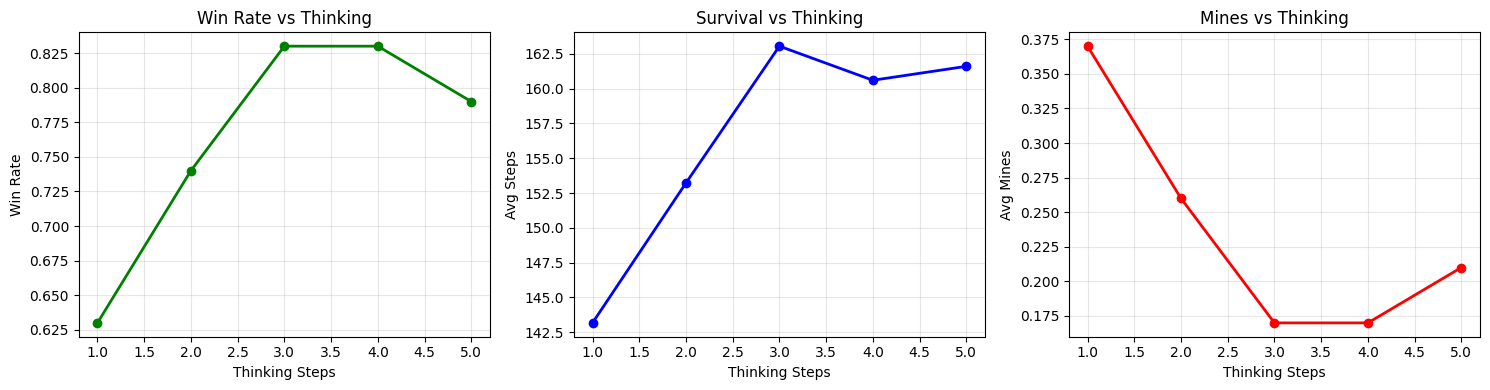

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
steps = list(results_by_thinking.keys())
win_rates = [results_by_thinking[s]['win_rate'] for s in steps]
avg_steps = [results_by_thinking[s]['avg_steps'] for s in steps]
avg_mines = [results_by_thinking[s]['avg_mines_triggered'] for s in steps]

axes[0].plot(steps, win_rates, marker='o')
axes[0].set_xlabel('Thinking Steps')
axes[0].set_ylabel('Win Rate')
axes[0].set_title('Win Rate vs Thinking')
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, avg_steps, marker='o')
axes[1].set_xlabel('Thinking Steps')
axes[1].set_ylabel('Avg Steps')
axes[1].set_title('Survival vs Thinking')
axes[1].grid(True, alpha=0.3)

axes[2].plot(steps, avg_mines, marker='o')
axes[2].set_xlabel('Thinking Steps')
axes[2].set_ylabel('Avg Mines')
axes[2].set_title('Mines vs Thinking')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Output 4 [output4.png] stats v.s. thinking steps

It seems like 3 steps gives an optimal result overall. It's a point where shorter steps lead to prediction that's too close to baseline and longer steps leads to risk of errors. 

In [ ]:
# Generate a test board with some revealed cells
test_env = MinesweeperEnv(size=22, num_mines=80)
test_state = test_env.reset()

# Play a few moves with logic bot to create interesting state
logic_bot = LogicBot()
logic_bot.reset(22)
for _ in range(8):  # Reveal ~8 cells
    cell = logic_bot.select_cell(test_state)
    if cell:
        test_state, _, done, _ = test_env.step(cell[0], cell[1])
        if done:
            test_state = test_env.reset()
            logic_bot.reset(22)
            break

In [ ]:
recurrent_model.eval()
num_steps=5
features = state_to_features(test_state)
features_tensor = torch.FloatTensor(features).unsqueeze(0).to(device)

with torch.no_grad():
    all_preds = model.forward_with_thinking(features_tensor, num_steps=num_steps)

predictions = [pred.squeeze(0).cpu().numpy() for pred in all_preds]

# mask revealed cells, don't plot unrevealed cells
for pred in predictions:
    pred[test_state >= 0] = np.nan

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# board state
ax = axes[0]
display_state = test_state.copy().astype(float)
display_state[display_state == -1] = np.nan
im = ax.imshow(display_state, cmap='gray', vmin=0, vmax=8)
ax.set_title('Board State')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.047)

# thinking steps
for step_idx in range(num_steps):
    ax = axes[step_idx + 1]
    pred = predictions[step_idx]

    # red: likely mine, green: likely safe
    im = ax.imshow(pred, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_title(f'Thinking Step {step_idx + 1}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, label='Confidence')

plt.tight_layout()
plt.show()

for step_idx in range(num_steps):
    pred = predictions[step_idx]
    valid_preds = pred[~np.isnan(pred)]
    print(f'Step {step_idx + 1}')
    print('Mean: {valid_preds.mean():.3f} 'f'Std: {valid_preds.std():.3f} 'f'Min: {valid_preds.min():.3f} Max: {valid_preds.max():.3f}')

    high_conf_safe = (valid_preds > 0.8).sum()
    high_conf_mine = (valid_preds < 0.2).sum()
    uncertainty = ((valid_preds >= 0.4) & (valid_preds <= 0.6)).sum()
    print(f'High Confidence Safe: {high_conf_safe}, '
            f'High Confidence Mine: {high_conf_mine}, '
            f'Uncertainty: {uncertainty}')



Step 1 
Mean: 0.813, Std: 0.120, Min: 0.001, Max: 0.994
High Confidence Safe: 425, High Confidence Mine: 9, Uncertainty: 3
Step 2
Mean: 0.813, Std: 0.122, Min: 0.001, Max: 0.997
High Confidence Safe: 423, High Confidence Mine: 10, Uncertainty: 2
Step 3
Mean: 0.813, Std: 0.123, Min: 0.002, Max: 0.996
High Confidence Safe: 424, High Confidence Mine: 10, Uncertainty: 2
Step 4
Mean: 0.813, Std: 0.124, Min: 0.002, Max: 0.995
High Confidence Safe: 424, High Confidence Mine: 10, Uncertainty: 2
Step 5
Mean: 0.813, Std: 0.124, Min: 0.002, Max: 0.995
High Confidence Safe: 424, High Confidence Mine: 10, Uncertainty: 2

Output 5 [output5.png] Heat map of the board state over thinking steps. Black cells are revealed, white cells are unrevealed, and gray cells are weighted with number of adjacent mines. 

As the heat map suggests, the model is identifying boundary cells, which usually contain more information about where mines are. Distant cells are considered as generally safe, as suggested empirically.  